# VNM Stock EDA
Exploratory Data Analysis — 8 nhóm theo phân loại dữ liệu.

| Nhóm | Tên | Trường chính |
|------|-----|--------------|
| G1 | Giá Gốc (OHLCV) | date, open, high, low, close, volume |
| G2 | Đường Trung Bình | sma_10, sma_20, ema_20 |
| G3 | Động lượng & Xu hướng | macd_histogram, rsi_14, cci_14, momentum_10, roc_12 |
| G4 | Tỷ suất Sinh lời | log_return, return_lag_1~5 |
| G5 | Cấu trúc Nến | body_size, daily_range, upper_shadow, lower_shadow |
| G6 | Chỉ báo Khối lượng | obv, volume_sma_20, volume_ratio, volume_change, price_volume |
| G7 | Biến động | atr_14, rolling_std_20, historical_volatility_20 |
| G8 | Thống kê Cửa sổ trượt & Thị trường | rolling_max/min_20, distance_from_high/low_20, vnindex, vnindex_volume, vnindex_return, correlation_market_20, beta_20 |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

DATA_PATH = 'VNM_2225.csv'  # adjust if needed

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Loaded {len(df)} rows | {df["date"].min().date()} → {df["date"].max().date()}')
df.head(3)

Loaded 913 rows | 2021-10-29 → 2025-06-30


,date,open,high,low,close,volume,sma_10,sma_20,ema_20,macd_histogram,...,volume_sma_20,volume_ratio,volume_change,price_volume,vnindex,vnindex_volume,vnindex_return,correlation_market_20,beta_20,day_of_week
0,2021-10-29,70.98,71.29,70.75,71.06,3748500,NaN,NaN,71.060000,0.000000,...,NaN,NaN,NaN,266368410.0,1444.27,904699600,NaN,NaN,NaN,4
1,2021-11-01,71.14,71.53,70.35,70.51,5083800,NaN,NaN,71.007619,-0.035100,...,NaN,NaN,0.356222,358458738.0,1438.97,1052909000,-0.003670,NaN,NaN,0
2,2021-11-02,70.51,70.51,69.73,69.88,4888900,NaN,NaN,70.900227,-0.095385,...,NaN,NaN,-0.038337,341636332.0,1452.46,942151100,0.009375,NaN,NaN,1



## CONFIG — Bật/tắt từng trường theo nhóm

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# NHÓM 1 — Giá Gốc (OHLCV)
# ─────────────────────────────────────────────────────────────────────────────
G1 = {
    'open':   True,
    'high':   True,
    'low':    True,
    'close':  True,
    'volume': True,
}

# ─────────────────────────────────────────────────────────────────────────────
# NHÓM 2 — Đường Trung Bình (Moving Averages)
# ─────────────────────────────────────────────────────────────────────────────
G2 = {
    'sma_10': True,
    'sma_20': True,
    'ema_20': True,
}

# ─────────────────────────────────────────────────────────────────────────────
# NHÓM 3 — Động lượng & Xu hướng (Momentum/Trend Indicators)
# ─────────────────────────────────────────────────────────────────────────────
G3 = {
    'macd_histogram': True,
    'rsi_14':         True,
    'cci_14':         True,
    'momentum_10':    True,
    'roc_12':         True,
}

# ─────────────────────────────────────────────────────────────────────────────
# NHÓM 4 — Tỷ suất Sinh lời (Return Features)
# ─────────────────────────────────────────────────────────────────────────────
G4 = {
    'log_return':   True,
    'return_lag_1': True,
    'return_lag_2': True,
    'return_lag_3': True,
    'return_lag_4': True,
    'return_lag_5': True,
}

# ─────────────────────────────────────────────────────────────────────────────
# NHÓM 5 — Cấu trúc Nến (Candlestick/Price Structure)
# ─────────────────────────────────────────────────────────────────────────────
G5 = {
    'body_size':    True,
    'daily_range':  True,
    'upper_shadow': True,
    'lower_shadow': True,
}

# ─────────────────────────────────────────────────────────────────────────────
# NHÓM 6 — Chỉ báo Khối lượng (Volume Indicators)
# ─────────────────────────────────────────────────────────────────────────────
G6 = {
    'obv':           True,
    'volume_sma_20': True,
    'volume_ratio':  True,
    'volume_change': True,
    'price_volume':  True,
}

# ─────────────────────────────────────────────────────────────────────────────
# NHÓM 7 — Biến động (Volatility)
# ─────────────────────────────────────────────────────────────────────────────
G7 = {
    'atr_14':                  True,
    'rolling_std_20':           True,
    'historical_volatility_20': True,
}

# ─────────────────────────────────────────────────────────────────────────────
# NHÓM 8 — Thống kê Cửa sổ trượt & Bối cảnh Thị trường
# (Rolling Stats & Market Context)
# ─────────────────────────────────────────────────────────────────────────────
G8 = {
    # Thống kê giá
    'rolling_max_20':        True,
    'rolling_min_20':        True,
    'distance_from_high_20': True,
    'distance_from_low_20':  True,
    # Thị trường chung
    'vnindex':               True,
    'vnindex_volume':        True,
    'vnindex_return':        True,
    'correlation_market_20': True,
    'beta_20':               True,
}

# ─── helpers (don't edit) ────────────────────────────────────────────────────
def active(cfg): return [k for k, v in cfg.items() if v and k in df.columns]

print('Active fields per group:')
for name, cfg in [('G1',G1),('G2',G2),('G3',G3),('G4',G4),
                  ('G5',G5),('G6',G6),('G7',G7),('G8',G8)]:
    print(f'  {name}: {active(cfg)}')

Active fields per group:
  G1: ['open', 'high', 'low', 'close', 'volume']
  G2: ['sma_10', 'sma_20', 'ema_20']
  G3: ['macd_histogram', 'rsi_14', 'cci_14', 'momentum_10', 'roc_12']
  G4: ['log_return', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_4', 'return_lag_5']
  G5: ['body_size', 'daily_range', 'upper_shadow', 'lower_shadow']
  G6: ['obv', 'volume_sma_20', 'volume_ratio', 'volume_change', 'price_volume']
  G7: ['atr_14', 'rolling_std_20', 'historical_volatility_20']
  G8: ['rolling_max_20', 'rolling_min_20', 'distance_from_high_20', 'distance_from_low_20', 'vnindex', 'vnindex_volume', 'vnindex_return', 'correlation_market_20', 'beta_20']


## Dataset Overview

In [4]:
print(f'Shape : {df.shape}')
print(f'Date  : {df.date.min().date()}  →  {df.date.max().date()}  ({len(df)} trading days)')
print()
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Missing values:')
display(missing.to_frame('count').assign(pct=lambda x: (x['count']/len(df)*100).round(2)))
print()
display(df.describe().T.round(4))

Shape : (913, 43)
Date  : 2021-10-29  →  2025-06-30  (913 trading days)

Missing values:


,count,pct
sma_10,9,0.99
sma_20,19,2.08
rsi_14,13,1.42
cci_14,13,1.42
momentum_10,10,1.10
roc_12,12,1.31
log_return,1,0.11
atr_14,13,1.42
rolling_std_20,19,2.08
historical_volatility_20,20,2.19


,count,mean,min,25%,50%,75%,max,std
date,913,2023-08-29 03:13:59.868565,2021-10-29 00:00:00,2022-09-29 00:00:00,2023-08-28 00:00:00,2024-07-29 00:00:00,2025-06-30 00:00:00,NaN
open,913.0,60.904995,47.42,58.38,60.4,63.92,71.29,4.19179
high,913.0,61.444775,50.92,58.86,60.74,64.61,71.53,4.203457
low,913.0,60.38736,47.42,57.88,59.81,63.42,70.75,4.144234
close,913.0,60.83874,47.97,58.27,60.23,63.95,71.14,4.197246
volume,913.0,2926878.797371,447884.0,1672065.0,2505912.0,3525626.0,21167413.0,1947991.862386
sma_10,904.0,60.824267,51.487,58.49425,60.179,63.81525,70.166,4.020951
sma_20,894.0,60.815351,52.0585,58.511125,60.39025,63.7465,69.4485,3.842838
ema_20,913.0,61.018004,52.909659,58.542691,60.644328,64.051973,71.06,3.955608
macd_histogram,913.0,0.000903,-0.83502,-0.144872,-0.000091,0.143709,0.688015,0.24271


---
## Nhóm 1 — Giá Gốc (OHLCV)
`date, open, high, low, close, volume`

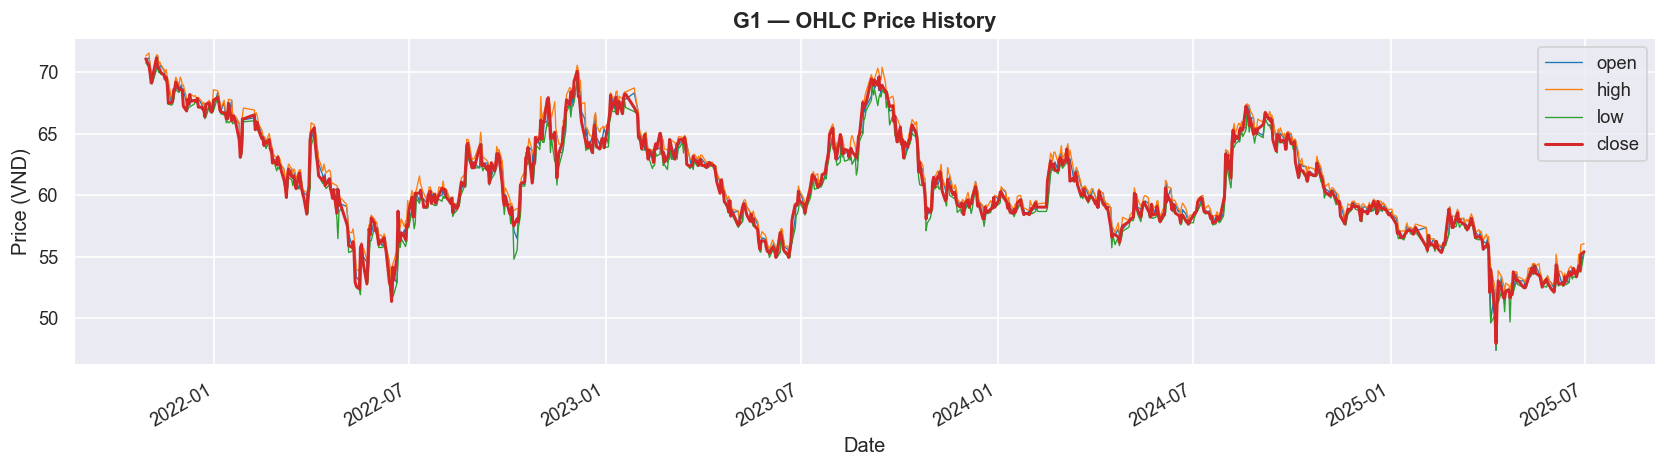

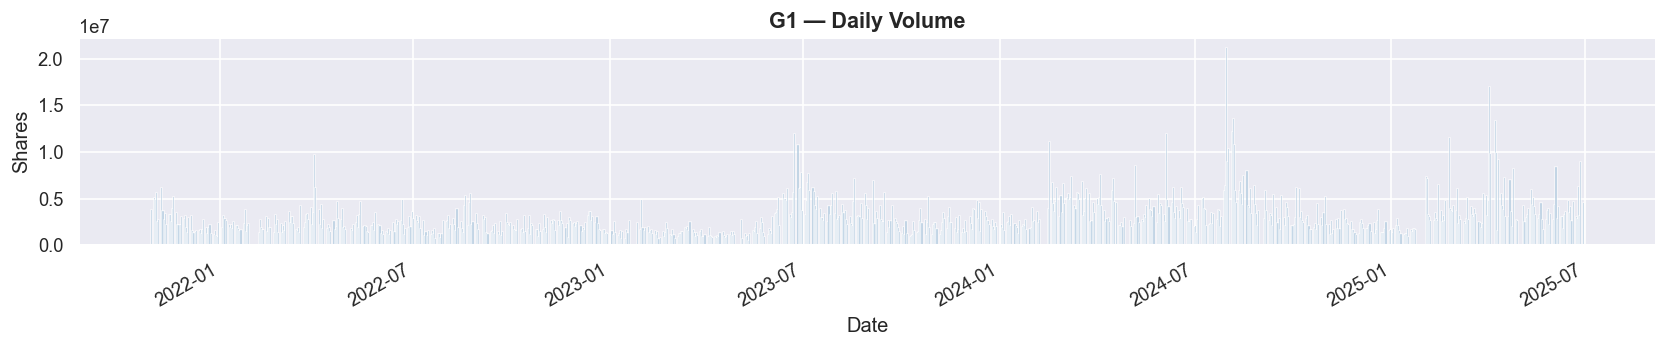

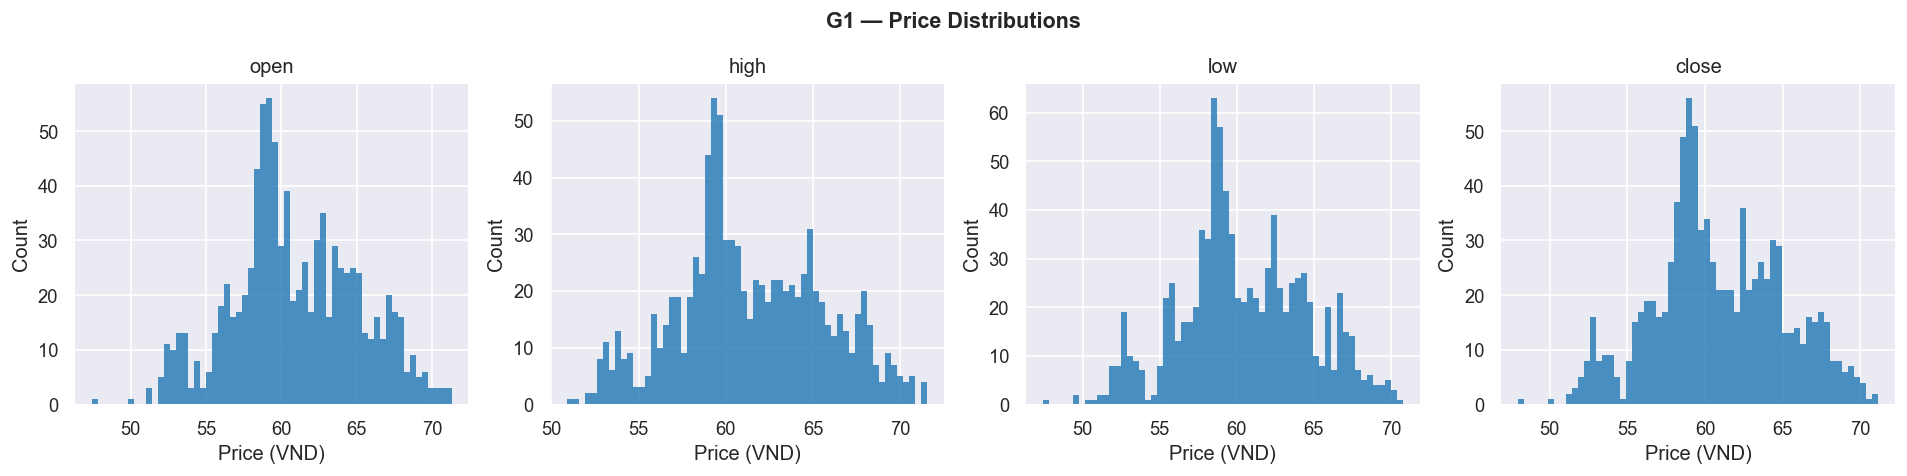

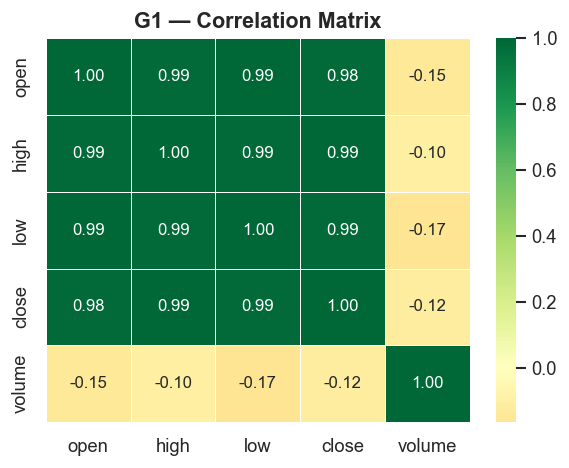

In [ ]:
cols = active(G1)
if not cols:
    print('All G1 fields disabled — skipping.')
else:
    price_cols  = [c for c in ['open','high','low','close'] if c in cols]
    volume_cols = [c for c in ['volume'] if c in cols]

    # ── 1a  OHLC line chart ──────────────────────────────────────────────────
    if price_cols:
        fig, ax = plt.subplots(figsize=(14, 4))
        for c in price_cols:
            lw = 1.8 if c == 'close' else 0.8
            ax.plot(df.date, df[c], label=c, linewidth=lw)
        ax.set_title('G1 — OHLC Price History', fontsize=13, fontweight='bold')
        ax.set_xlabel('Date'); ax.set_ylabel('Price (VND)')
        ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()
        plt.tight_layout(); plt.show()

    # ── 1b  Volume bar chart ─────────────────────────────────────────────────
    if volume_cols:
        fig, ax = plt.subplots(figsize=(14, 3))
        ax.bar(df.date, df.volume, color='steelblue', alpha=0.6, width=1, label='volume')
        ax.set_title('G1 — Daily Volume', fontsize=13, fontweight='bold')
        ax.set_xlabel('Date'); ax.set_ylabel('Shares')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()
        plt.tight_layout(); plt.show()

    # ── 1c  Price distributions ──────────────────────────────────────────────
    if price_cols:
        n = len(price_cols)
        fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
        if n == 1: axes = [axes]
        for ax, c in zip(axes, price_cols):
            ax.hist(df[c].dropna(), bins=60, edgecolor='none', alpha=0.8)
            ax.set_title(c); ax.set_xlabel('Price (VND)'); ax.set_ylabel('Count')
        fig.suptitle('G1 — Price Distributions', fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

## Nhóm 2 — Đường Trung Bình (Moving Averages)
`sma_10, sma_20, ema_20`

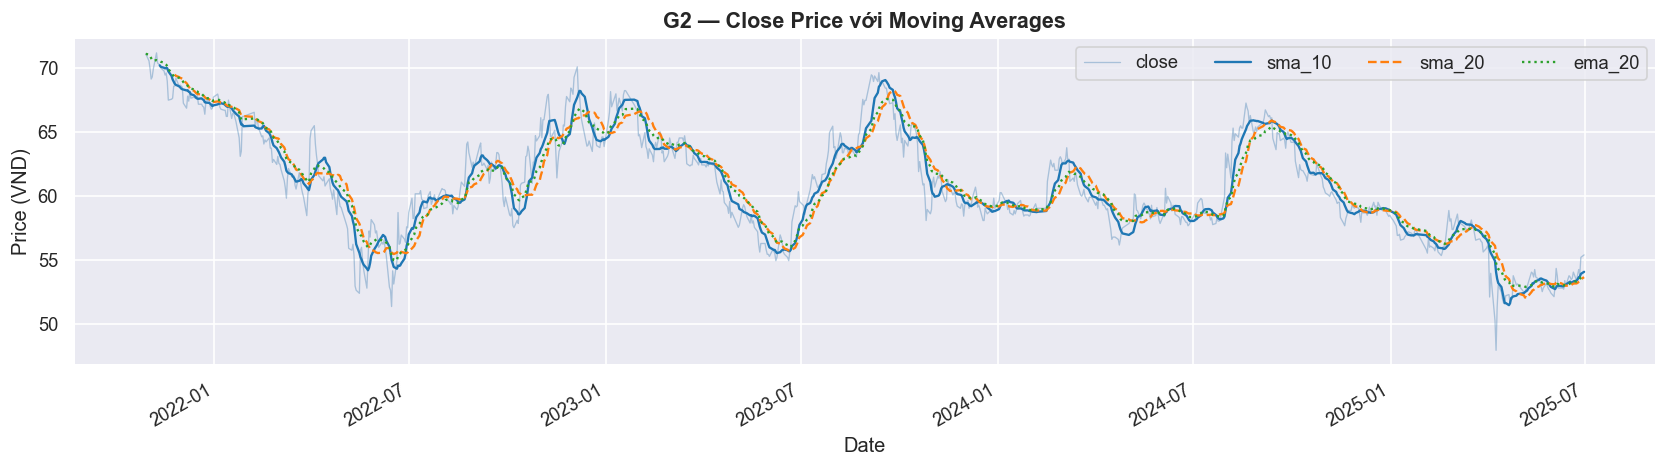

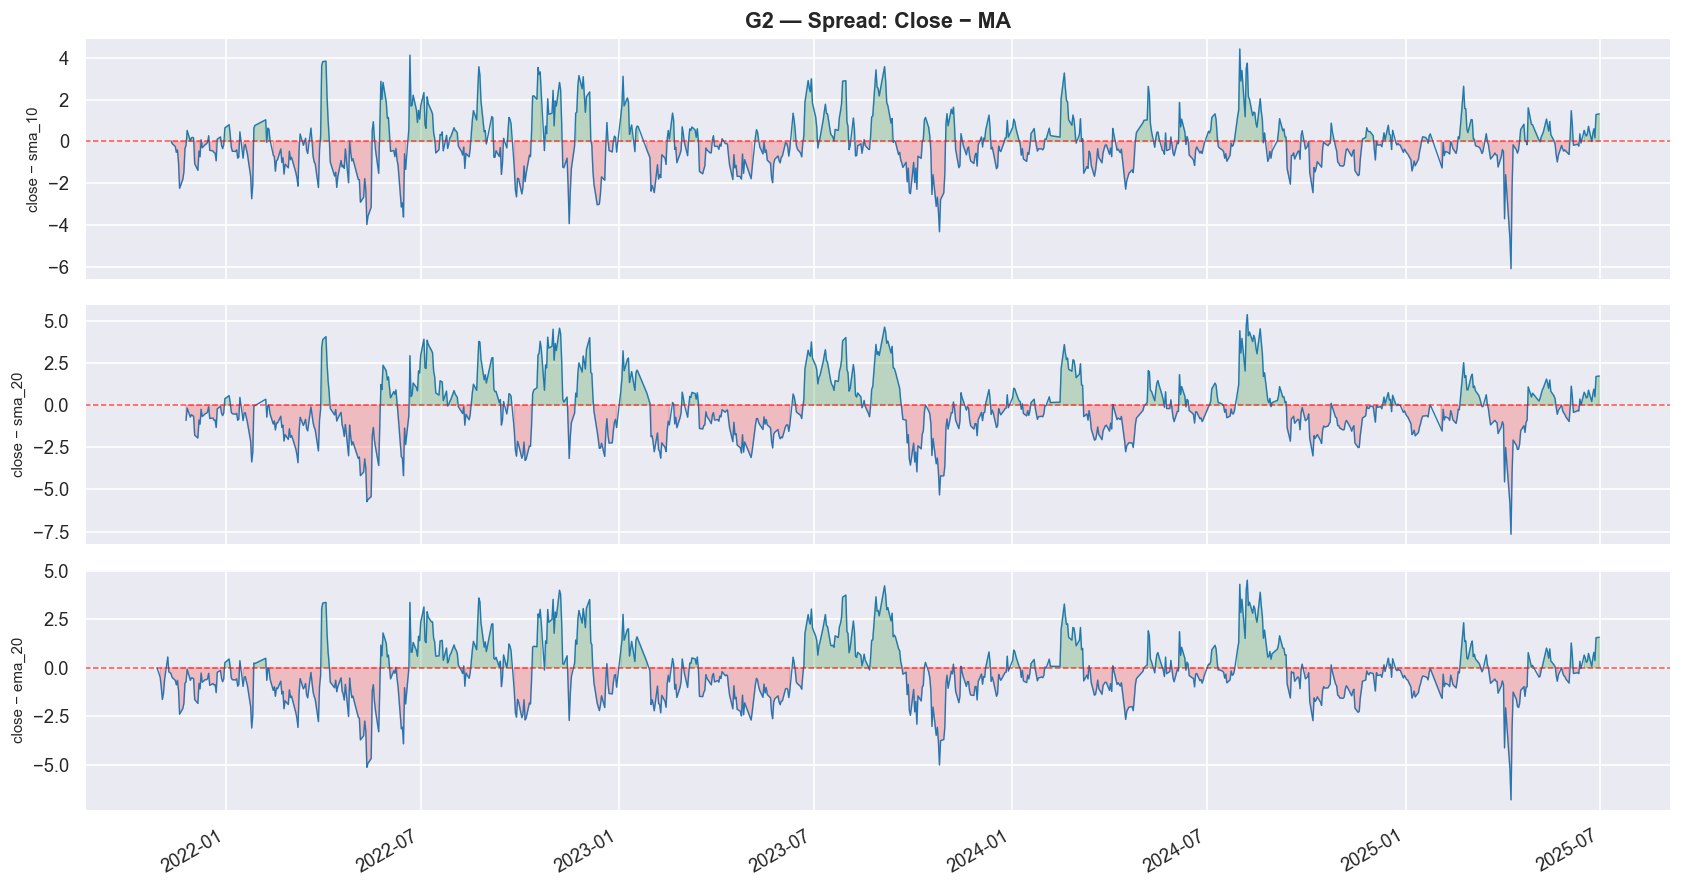

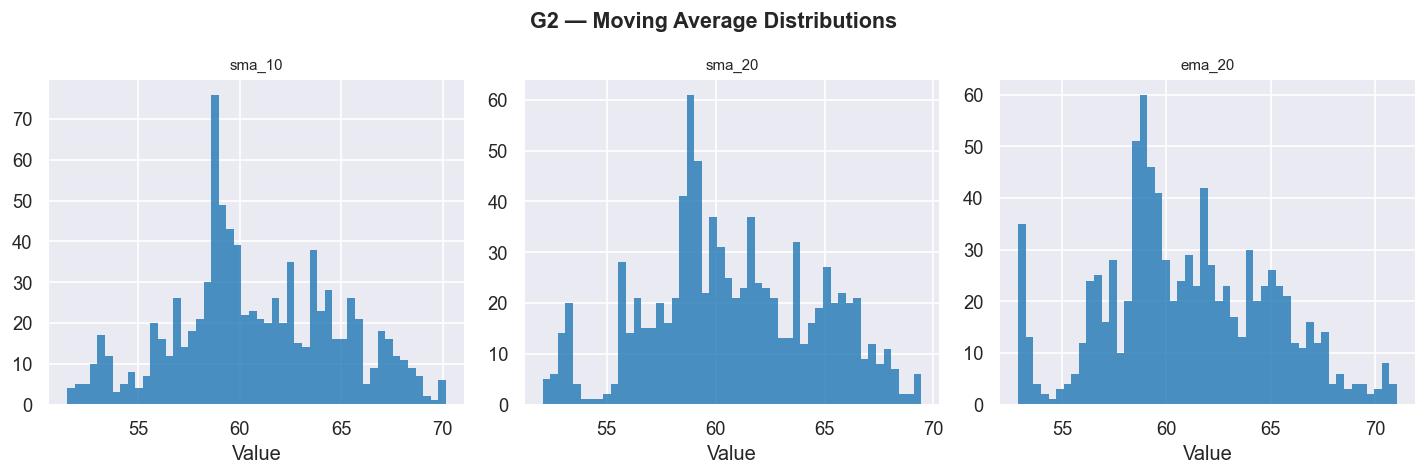

In [6]:
cols = active(G2)
if not cols:
    print('All G2 fields disabled — skipping.')
else:
    # ── 2a  Close + Moving Averages overlay ─────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df.date, df.close, color='steelblue', alpha=0.4, linewidth=0.8, label='close')
    styles = ['-', '--', ':']
    for i, c in enumerate(cols):
        ax.plot(df.date, df[c], linestyle=styles[i % 3], linewidth=1.4, label=c)
    ax.set_title('G2 — Close Price với Moving Averages', fontsize=13, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Price (VND)')
    ax.legend(ncol=4); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    plt.tight_layout(); plt.show()

    # ── 2b  Spread: close − MA ───────────────────────────────────────────────
    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=True)
    if n == 1: axes = [axes]
    for ax, c in zip(axes, cols):
        spread = df.close - df[c]
        ax.plot(df.date, spread, linewidth=0.8)
        ax.axhline(0, color='red', linewidth=0.9, linestyle='--', alpha=0.7)
        ax.fill_between(df.date, spread, 0,
                         where=(spread > 0), alpha=0.2, color='green')
        ax.fill_between(df.date, spread, 0,
                         where=(spread < 0), alpha=0.2, color='red')
        ax.set_ylabel(f'close − {c}', fontsize=9)
    axes[0].set_title('G2 — Spread: Close − MA', fontsize=13, fontweight='bold')
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    plt.tight_layout(); plt.show()

    # ── 2c  Distribution of MA values ───────────────────────────────────────
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for ax, c in zip(axes, cols):
        ax.hist(df[c].dropna(), bins=50, edgecolor='none', alpha=0.8)
        ax.set_title(c, fontsize=9); ax.set_xlabel('Value')
    fig.suptitle('G2 — Moving Average Distributions', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

## Nhóm 3 — Động lượng & Xu hướng (Momentum/Trend Indicators)
`macd_histogram, rsi_14, cci_14, momentum_10, roc_12`

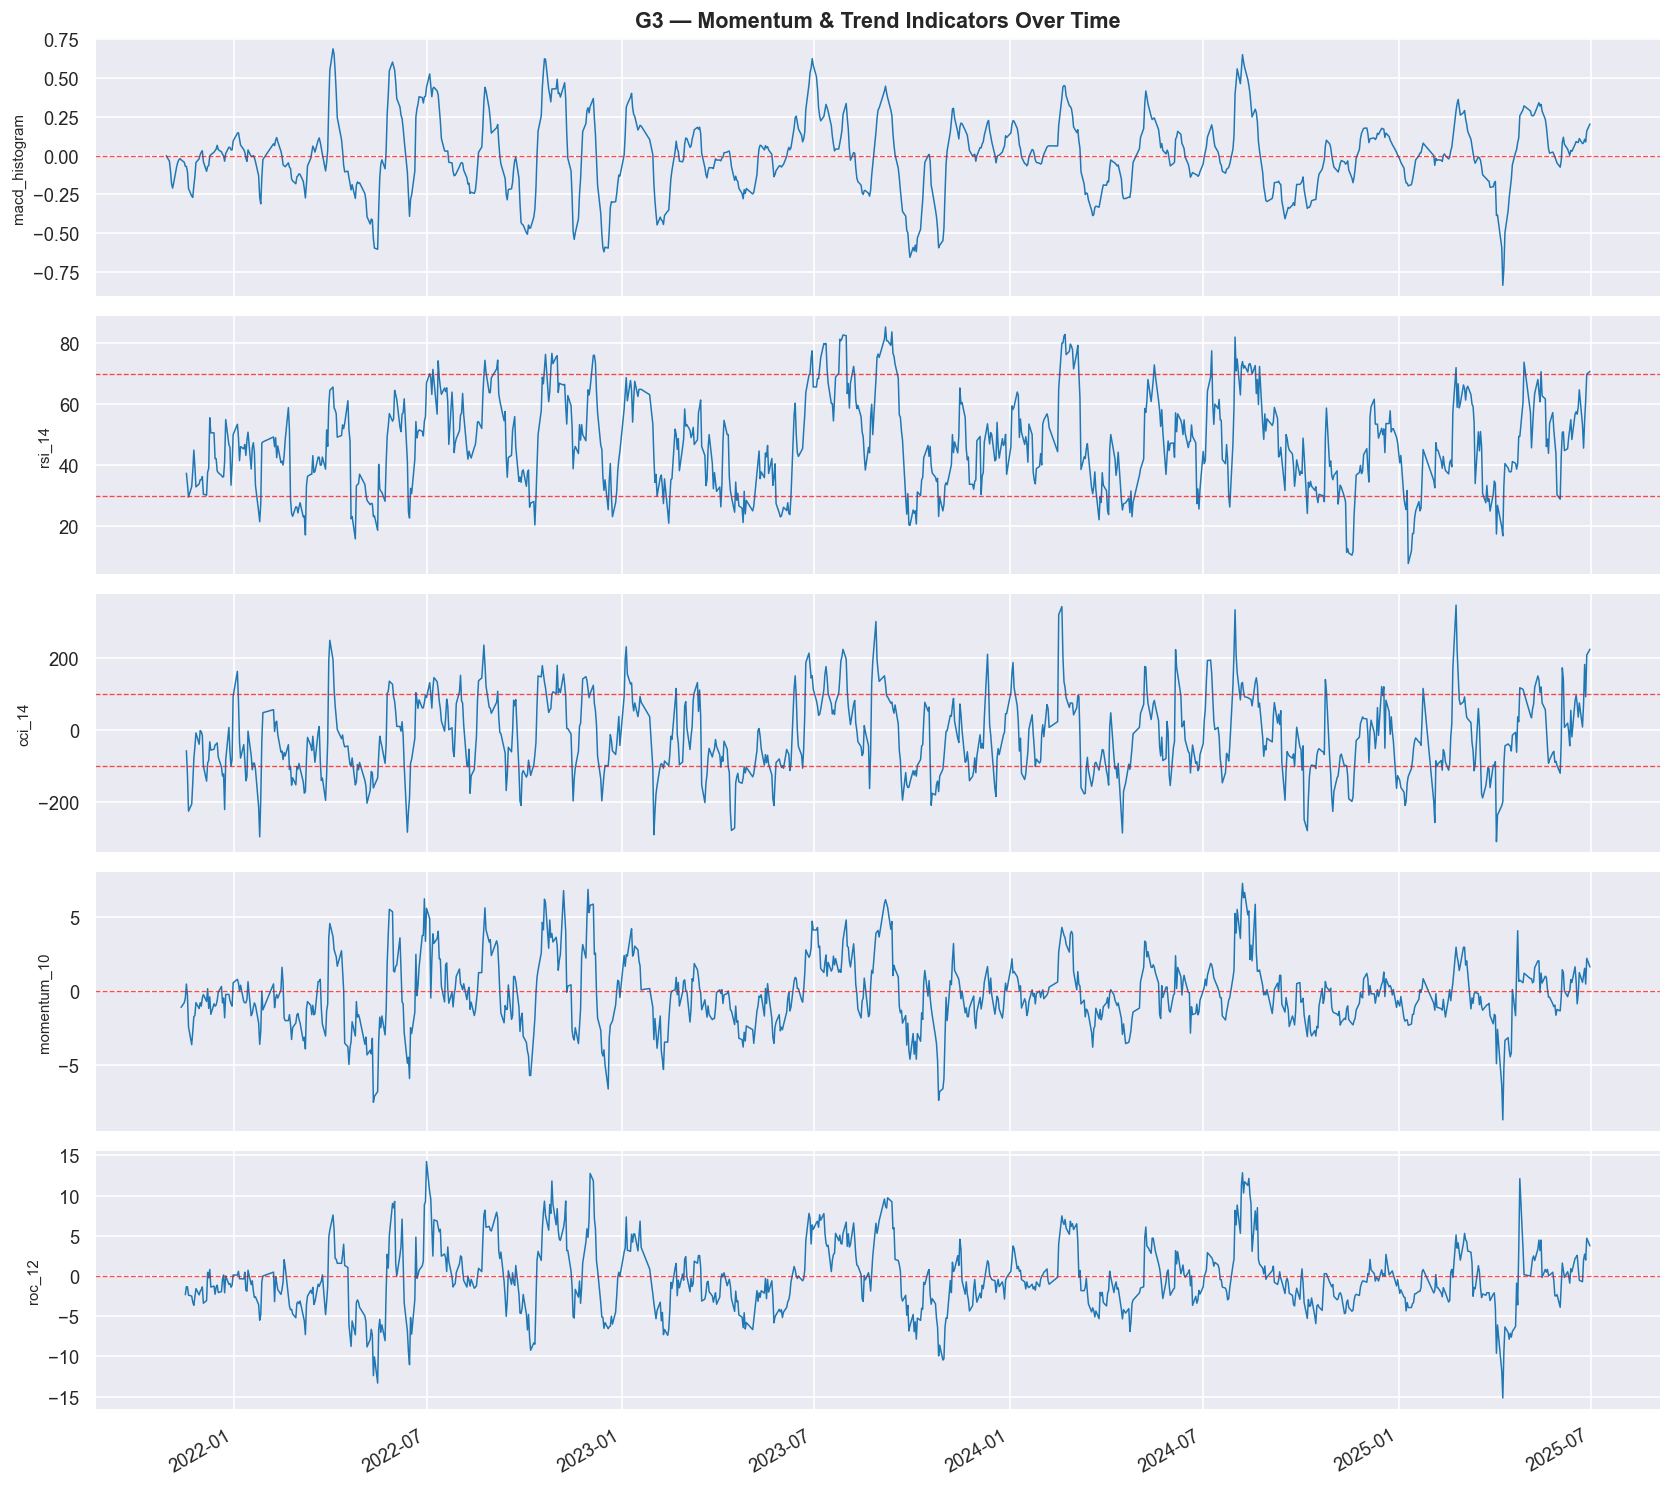

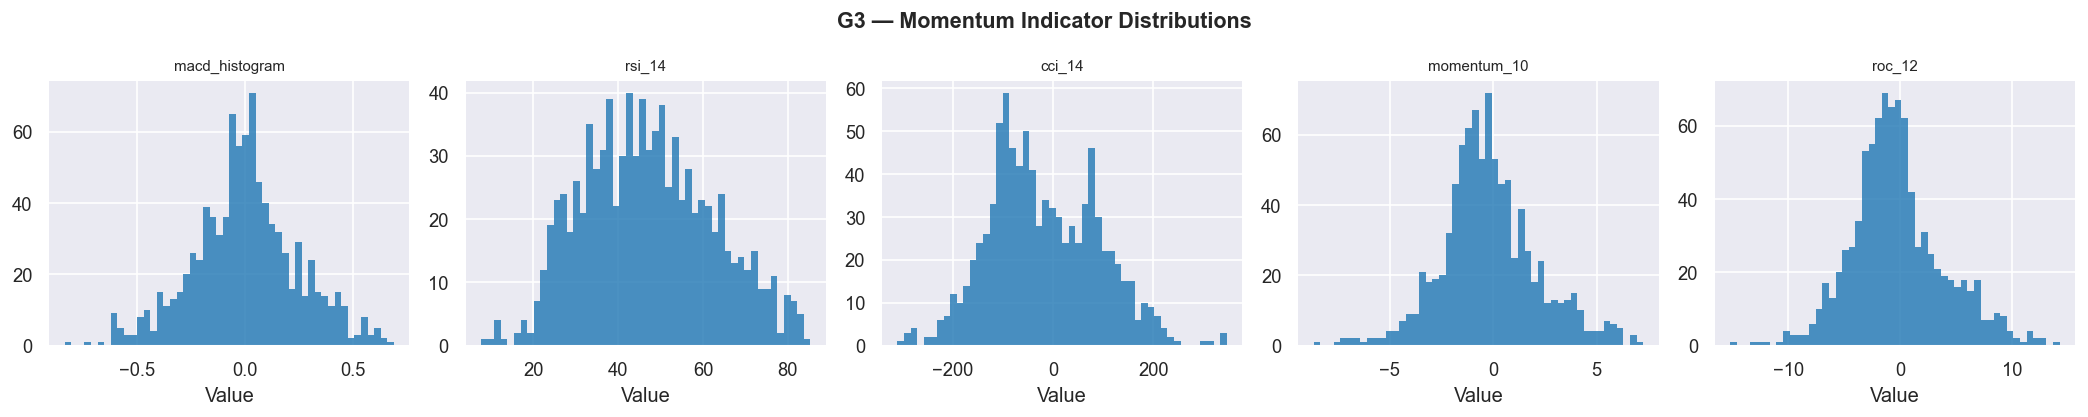

In [ ]:
cols = active(G3)
if not cols:
    print('All G3 fields disabled — skipping.')
else:
    # ── 3a  Time-series: one sub-panel per indicator ─────────────────────────
    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=True)
    if n == 1: axes = [axes]
    ref_lines = {
        'rsi_14':         [30, 70],
        'cci_14':         [-100, 100],
        'macd_histogram': [0],
        'momentum_10':    [0],
        'roc_12':         [0],
    }
    for ax, c in zip(axes, cols):
        ax.plot(df.date, df[c], linewidth=0.9)
        for lvl in ref_lines.get(c, []):
            ax.axhline(lvl, color='red', linewidth=0.8, linestyle='--', alpha=0.7)
        ax.set_ylabel(c, fontsize=9)
    axes[0].set_title('G3 — Momentum & Trend Indicators Over Time',
                      fontsize=13, fontweight='bold')
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    plt.tight_layout(); plt.show()

    # ── 3b  Distributions ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, n, figsize=(3.5*n, 3.5))
    if n == 1: axes = [axes]
    for ax, c in zip(axes, cols):
        ax.hist(df[c].dropna(), bins=50, edgecolor='none', alpha=0.8)
        ax.set_title(c, fontsize=9); ax.set_xlabel('Value')
    fig.suptitle('G3 — Momentu Indicator Distributions', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

## Nhóm 4 — Tỷ suất Sinh lời (Return Features)
`log_return, return_lag_1, return_lag_2, return_lag_3, return_lag_4, return_lag_5`

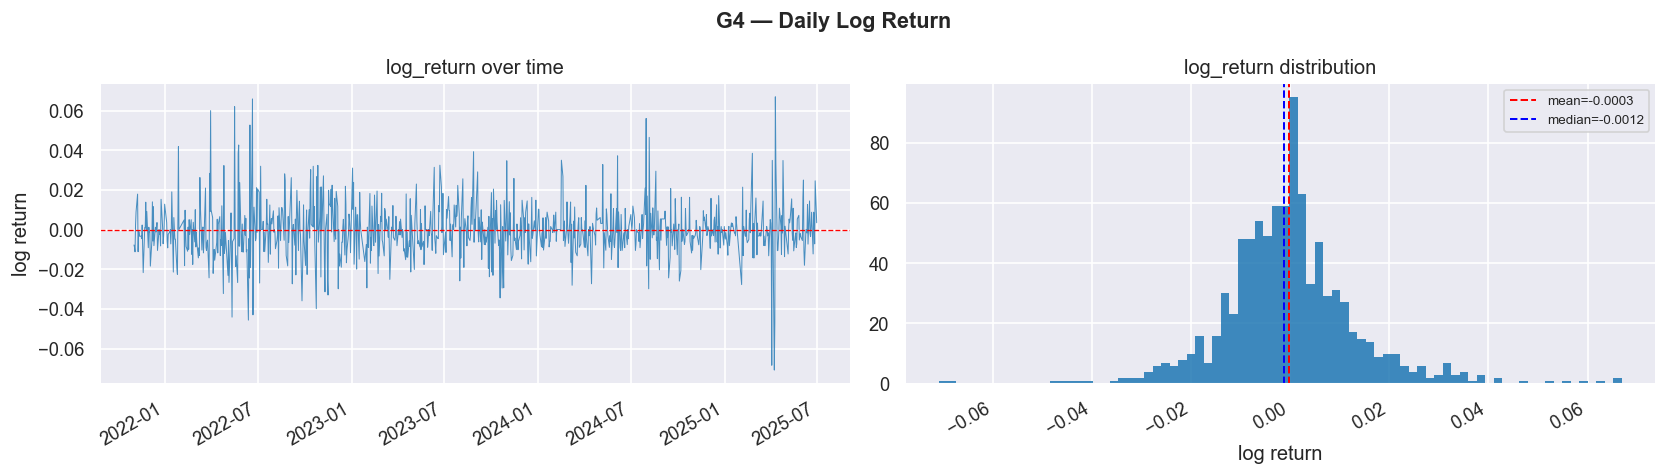

log_return stats:
  mean=-0.00027  std=0.01381  skew=0.425  kurt=4.027
  % positive days = 41.8%


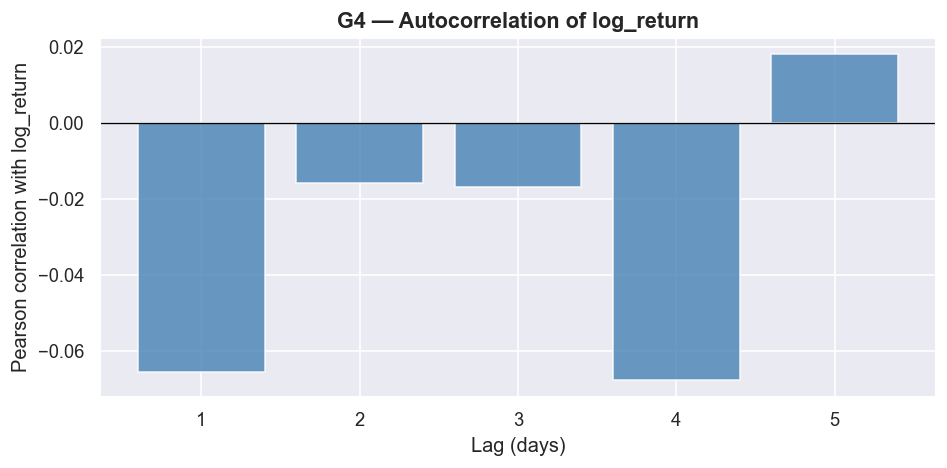

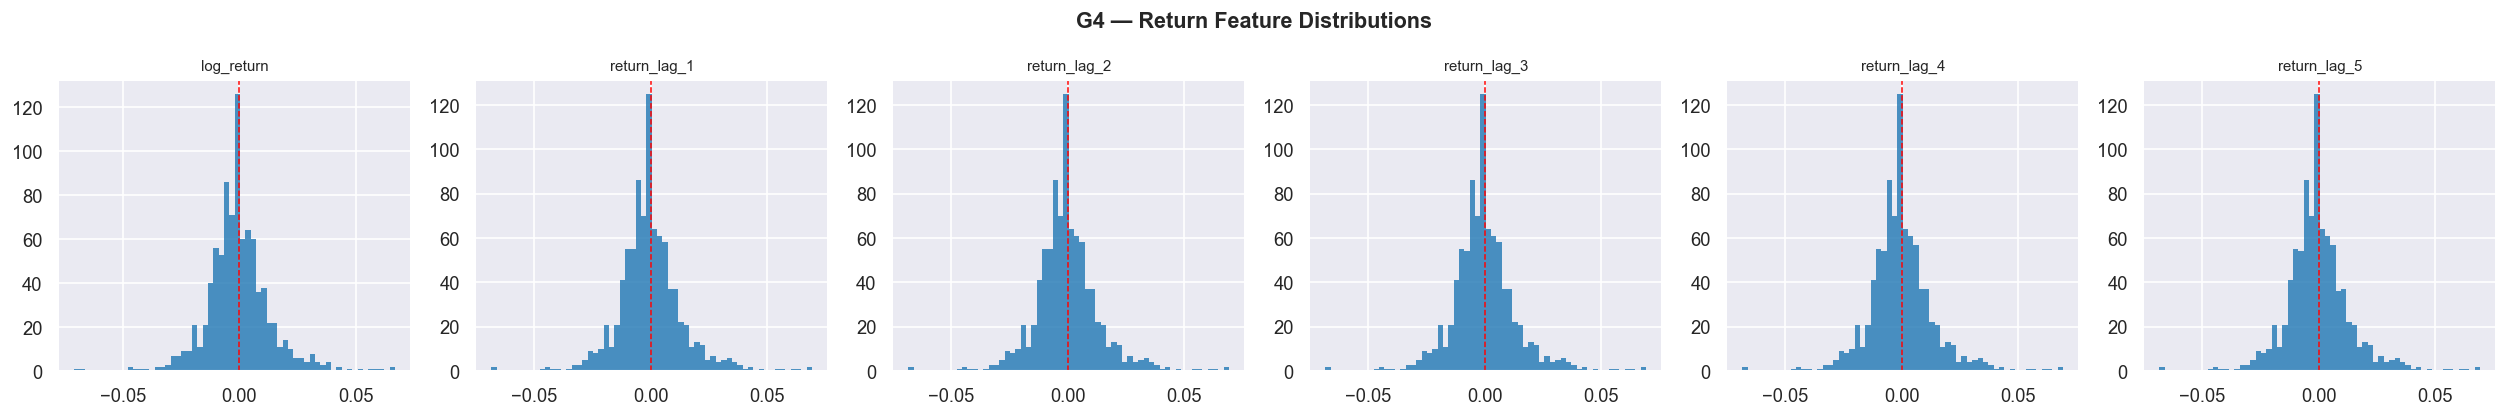

In [14]:
cols = active(G4)
if not cols:
    print('All G4 fields disabled — skipping.')
else:
    ret_col  = 'log_return' if 'log_return' in cols else None
    lag_cols = [c for c in ['return_lag_1','return_lag_2','return_lag_3',
                             'return_lag_4','return_lag_5'] if c in cols]

    # ── 4a  log_return over time ─────────────────────────────────────────────
    if ret_col:
        r = df['log_return'].dropna()
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].plot(df.date, df['log_return'], linewidth=0.6, alpha=0.8)
        axes[0].axhline(0, color='red', linewidth=0.8, linestyle='--')
        axes[0].set_title('log_return over time'); axes[0].set_ylabel('log return')
        axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        axes[1].hist(r, bins=80, edgecolor='none', alpha=0.85)
        axes[1].axvline(r.mean(),   color='red',  linewidth=1.2, linestyle='--',
                        label=f'mean={r.mean():.4f}')
        axes[1].axvline(r.median(), color='blue', linewidth=1.2, linestyle='--',
                        label=f'median={r.median():.4f}')
        axes[1].set_title('log_return distribution'); axes[1].set_xlabel('log return')
        axes[1].legend(fontsize=8)
        fig.suptitle('G4 — Daily Log Return', fontsize=13, fontweight='bold')
        fig.autofmt_xdate()
        plt.tight_layout(); plt.show()

        print('log_return stats:')
        print(f'  mean={r.mean():.5f}  std={r.std():.5f}  '
              f'skew={r.skew():.3f}  kurt={r.kurt():.3f}')
        print(f'  % positive days = {(r > 0).mean()*100:.1f}%')

    # ── 4b  Autocorrelation: log_return vs lagged returns ────────────────────
    if lag_cols and ret_col:
        fig, ax = plt.subplots(figsize=(8, 4))
        lag_corrs = [df['log_return'].corr(df[c]) for c in lag_cols]
        lag_nums  = [int(c.split('_')[-1]) for c in lag_cols]
        ax.bar(lag_nums, lag_corrs, color='steelblue', alpha=0.8)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Lag (days)'); ax.set_ylabel('Pearson correlation with log_return')
        ax.set_title('G4 — Autocorrelation of log_return', fontsize=13, fontweight='bold')
        ax.set_xticks(lag_nums)
        plt.tight_layout(); plt.show()

    # ── 4c  Lag return distributions ─────────────────────────────────────────
    if lag_cols:
        all_ret = [c for c in cols if c in df.columns]
        n = len(all_ret)
        fig, axes = plt.subplots(1, n, figsize=(3.5*n, 3.5))
        if n == 1: axes = [axes]
        for ax, c in zip(axes, all_ret):
            ax.hist(df[c].dropna(), bins=60, edgecolor='none', alpha=0.8)
            ax.axvline(0, color='red', linewidth=0.9, linestyle='--')
            ax.set_title(c, fontsize=9)
        fig.suptitle('G4 — Return Feature Distributions', fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

## Nhóm 5 — Cấu trúc Nến (Candlestick/Price Structure)
`body_size, daily_range, upper_shadow, lower_shadow`

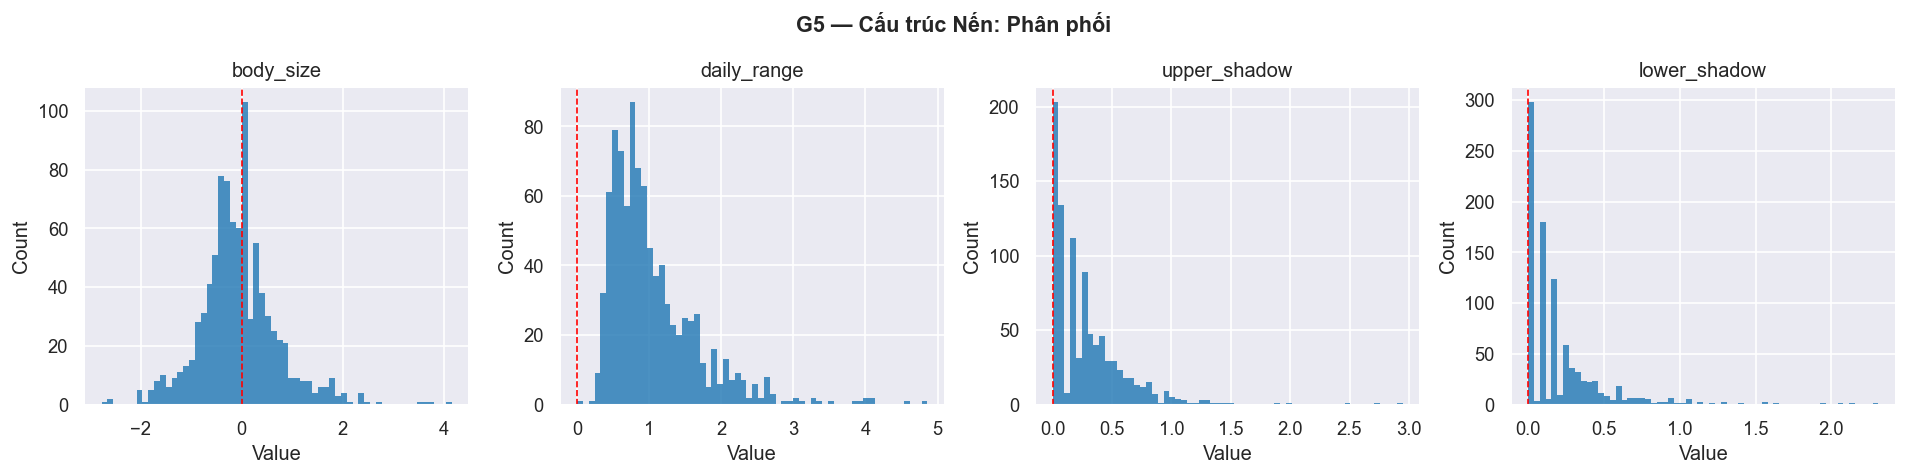

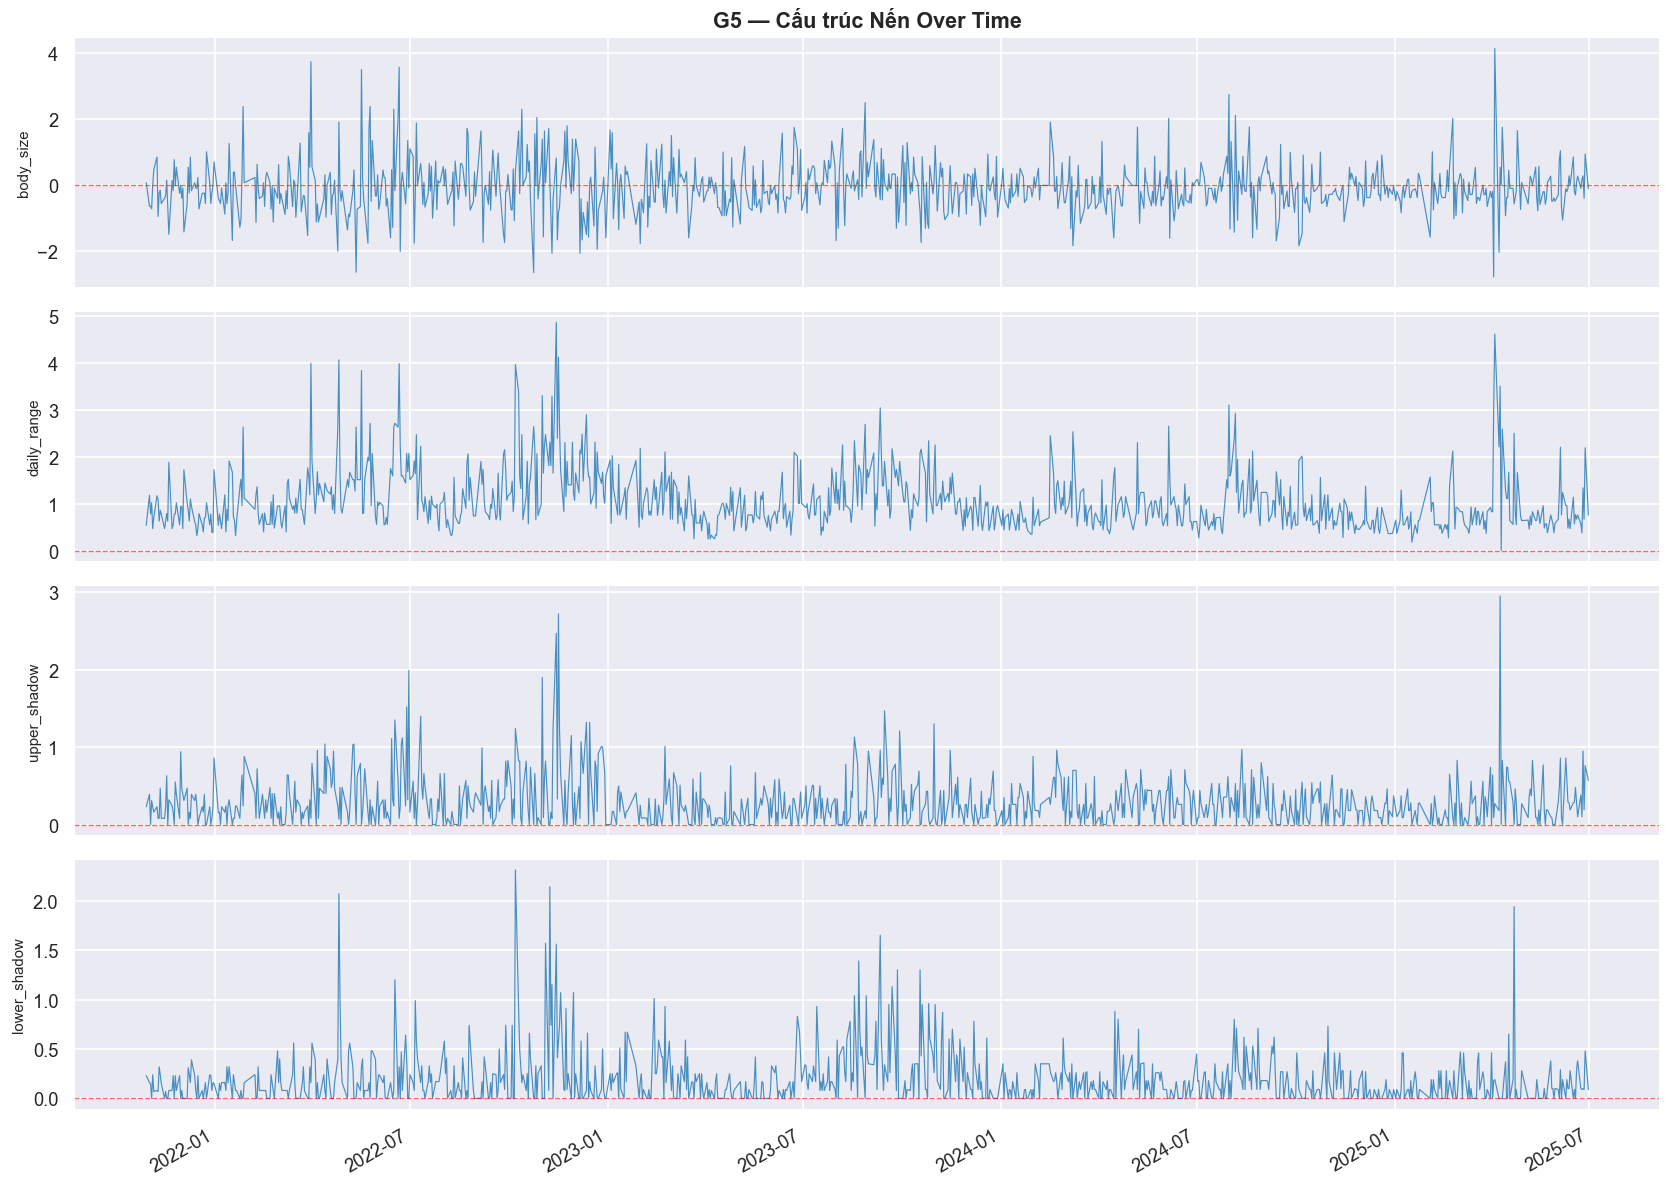

In [17]:
cols = active(G5)
if not cols:
    print('All G5 fields disabled — skipping.')
else:
    # ── 5a  Distributions of candlestick components ──────────────────────────
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for ax, c in zip(axes, cols):
        ax.hist(df[c].dropna(), bins=60, edgecolor='none', alpha=0.8)
        ax.axvline(0, color='red', linewidth=1, linestyle='--')
        ax.set_title(c); ax.set_xlabel('Value'); ax.set_ylabel('Count')
    fig.suptitle('G5 — Cấu trúc Nến: Phân phối', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # ── 5b  Time-series of each component ───────────────────────────────────
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=True)
    if n == 1: axes = [axes]
    for ax, c in zip(axes, cols):
        ax.plot(df.date, df[c], linewidth=0.7, alpha=0.8)
        ax.axhline(0, color='red', linewidth=0.8, linestyle='--', alpha=0.6)
        ax.set_ylabel(c, fontsize=9)
    axes[0].set_title('G5 — Cấu trúc Nến Over Time', fontsize=13, fontweight='bold')
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    plt.tight_layout(); plt.show()

## Nhóm 6 — Chỉ báo Khối lượng (Volume Indicators)
`obv, volume_sma_20, volume_ratio, volume_change, price_volume`

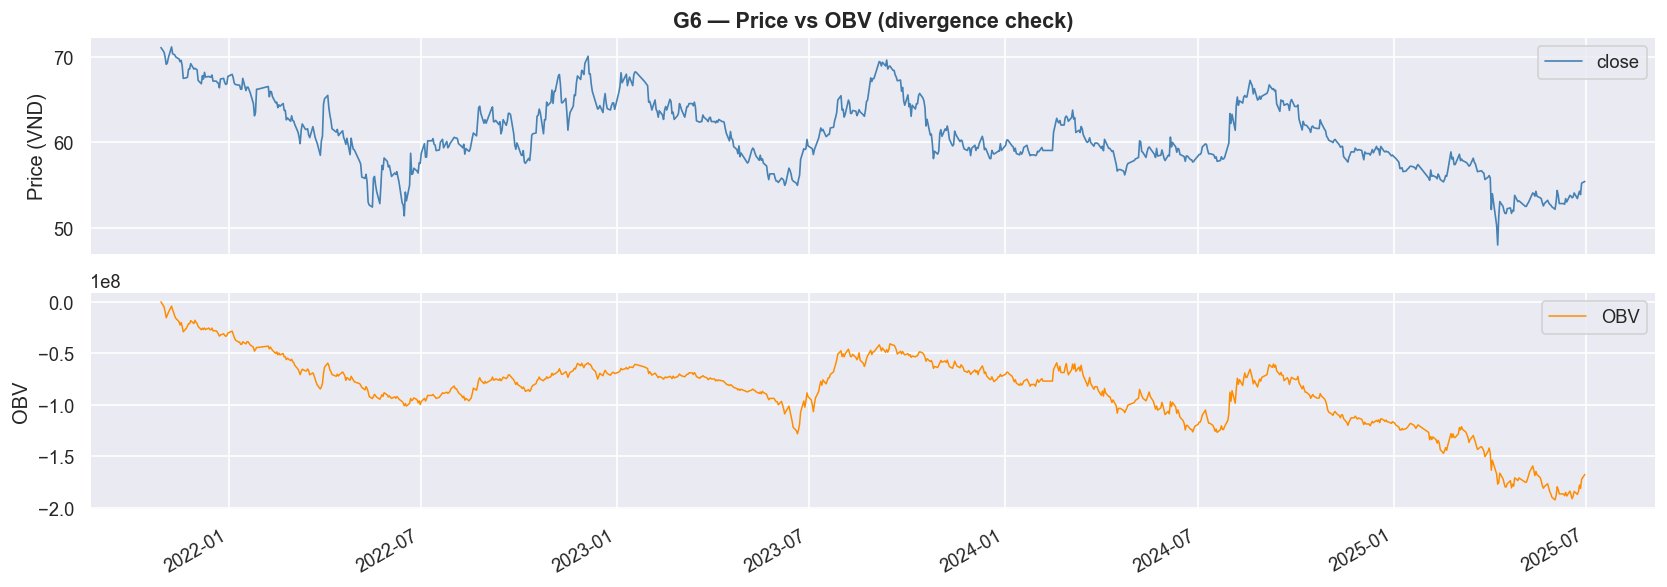

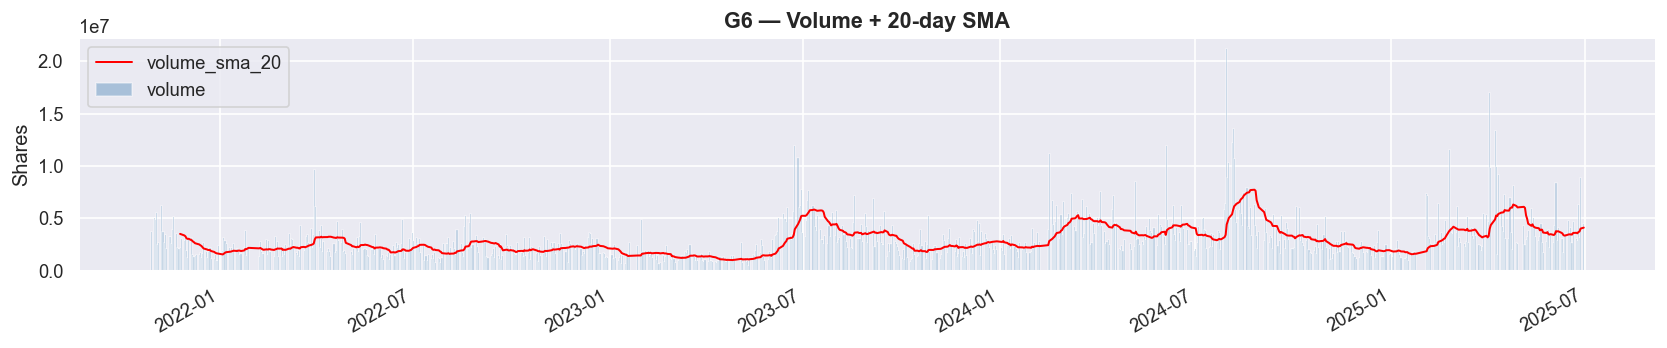

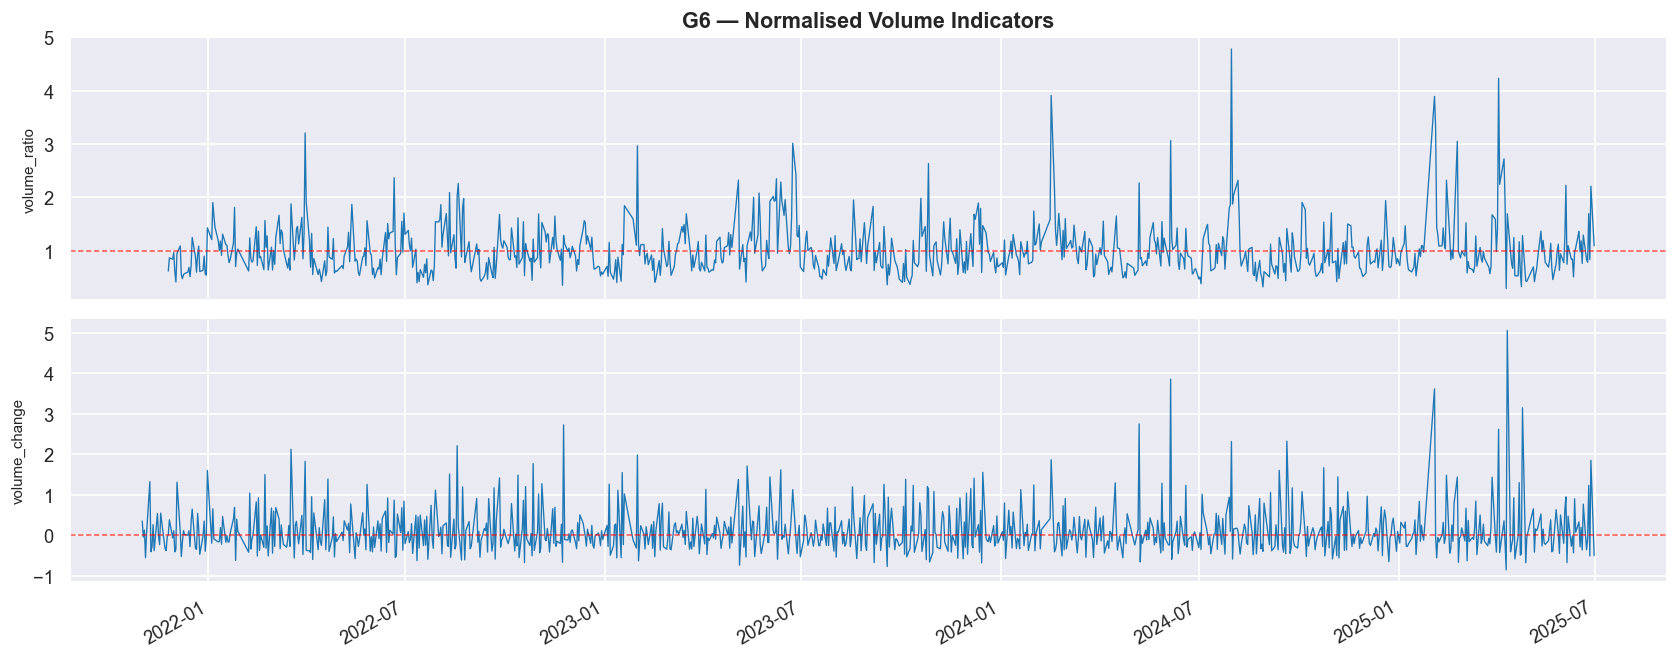

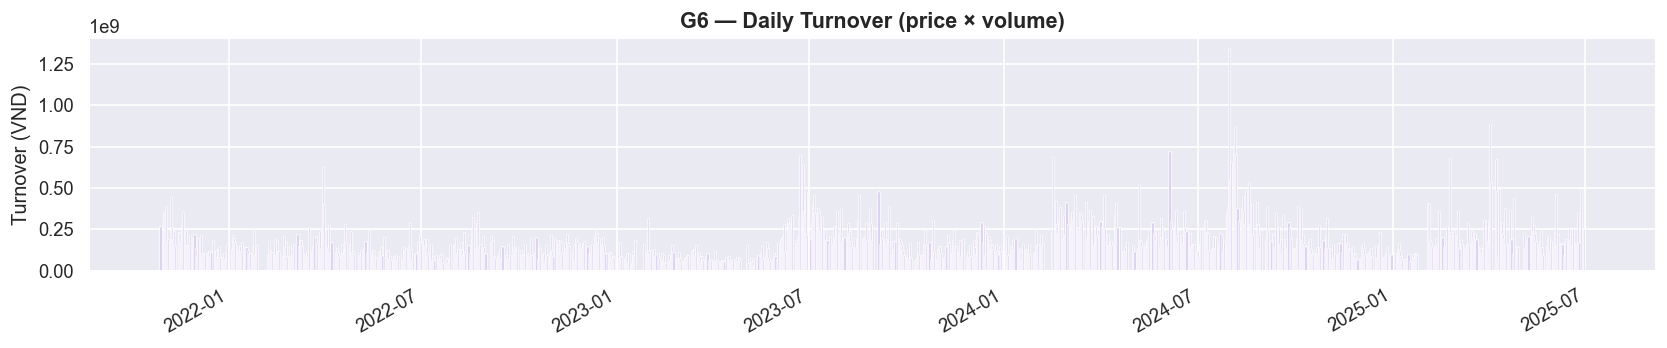

In [18]:
cols = active(G6)
if not cols:
    print('All G6 fields disabled — skipping.')
else:
    obv_col      = [c for c in ['obv'] if c in cols]
    vsma_col     = [c for c in ['volume_sma_20'] if c in cols]
    norm_cols    = [c for c in ['volume_ratio', 'volume_change'] if c in cols]
    pv_col       = [c for c in ['price_volume'] if c in cols]

    # ── 6a  OBV vs Close (divergence check) ─────────────────────────────────
    if obv_col:
        fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
        axes[0].plot(df.date, df.close, linewidth=1, color='steelblue', label='close')
        axes[0].set_ylabel('Price (VND)'); axes[0].legend()
        axes[1].plot(df.date, df.obv, linewidth=0.9, color='darkorange', label='OBV')
        axes[1].set_ylabel('OBV'); axes[1].legend()
        axes[0].set_title('G6 — Price vs OBV (divergence check)', fontsize=13, fontweight='bold')
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()
        plt.tight_layout(); plt.show()

    # ── 6b  volume_sma_20 vs raw volume (from G1) ───────────────────────────
    if vsma_col and 'volume' in df.columns:
        fig, ax = plt.subplots(figsize=(14, 3))
        ax.bar(df.date, df.volume, color='steelblue', alpha=0.4, width=1, label='volume')
        ax.plot(df.date, df.volume_sma_20, color='red', linewidth=1.2, label='volume_sma_20')
        ax.set_title('G6 — Volume + 20-day SMA', fontsize=13, fontweight='bold')
        ax.set_ylabel('Shares'); ax.legend()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()
        plt.tight_layout(); plt.show()

    # ── 6c  Normalised volume indicators ────────────────────────────────────
    if norm_cols:
        n_plots = len(norm_cols)
        fig, axes = plt.subplots(n_plots, 1, figsize=(14, 2.8*n_plots), sharex=True)
        if n_plots == 1: axes = [axes]
        ref = {'volume_ratio': 1.0, 'volume_change': 0}
        for ax, c in zip(axes, norm_cols):
            ax.plot(df.date, df[c], linewidth=0.8)
            ax.axhline(ref.get(c, 0), color='red', linewidth=0.9, linestyle='--', alpha=0.7)
            ax.set_ylabel(c, fontsize=9)
        axes[0].set_title('G6 — Normalised Volume Indicators', fontsize=13, fontweight='bold')
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()
        plt.tight_layout(); plt.show()

    # ── 6d  Daily turnover (price_volume) ────────────────────────────────────
    if pv_col:
        fig, ax = plt.subplots(figsize=(14, 3))
        ax.bar(df.date, df.price_volume, color='mediumpurple', alpha=0.7, width=1)
        ax.set_title('G6 — Daily Turnover (price × volume)', fontsize=13, fontweight='bold')
        ax.set_ylabel('Turnover (VND)')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()
        plt.tight_layout(); plt.show()

## Nhóm 7 — Biến động (Volatility)
`atr_14, rolling_std_20, historical_volatility_20`

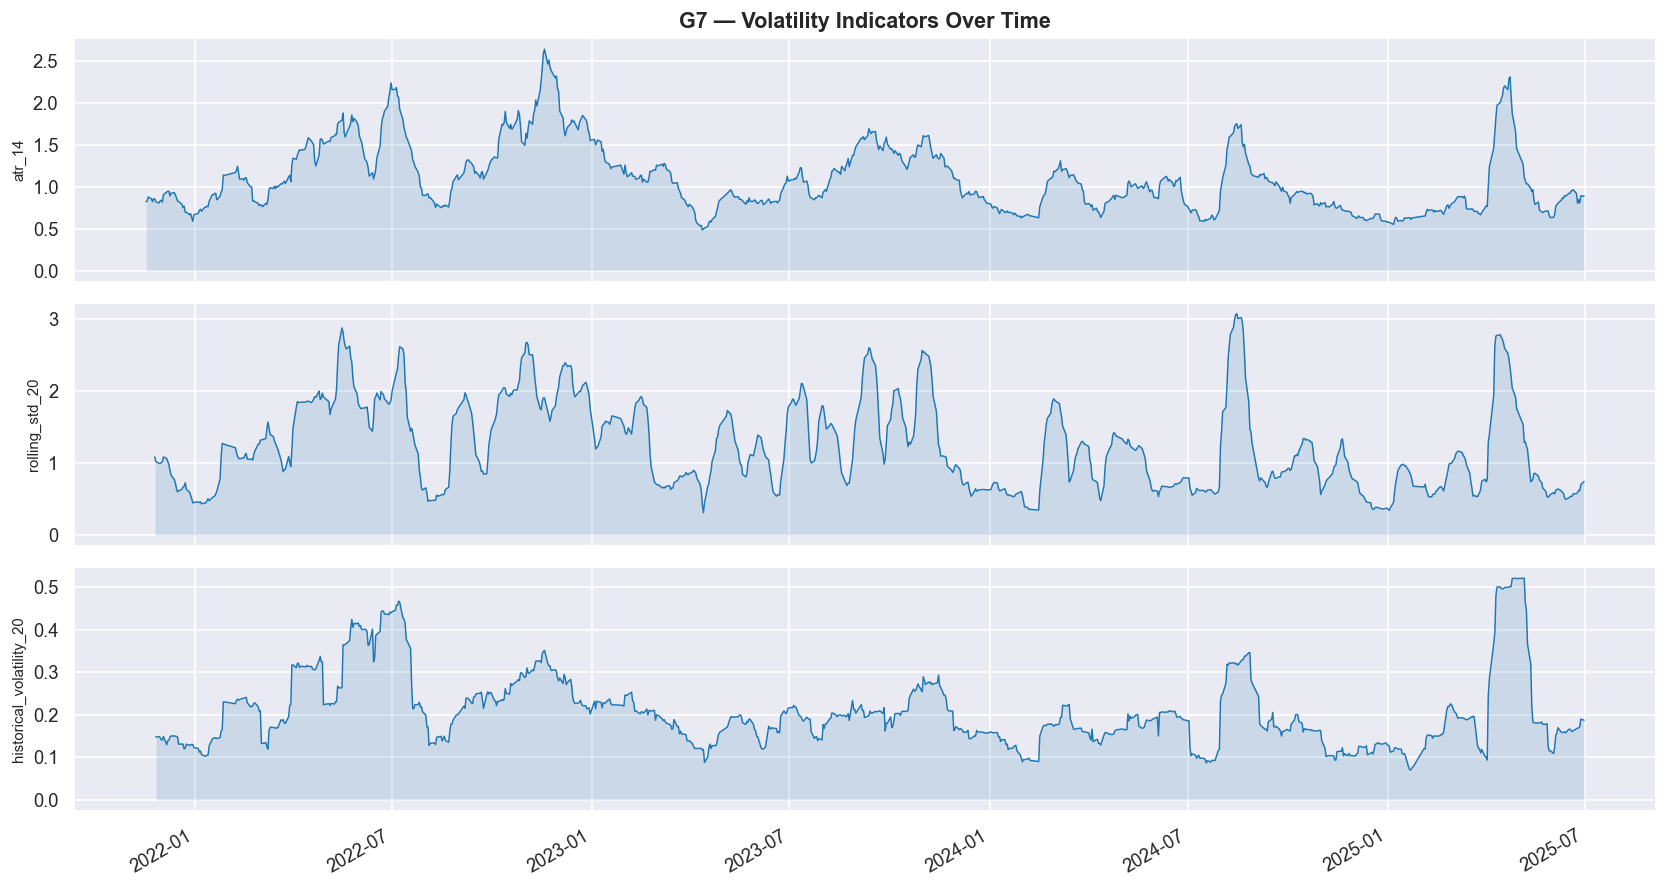

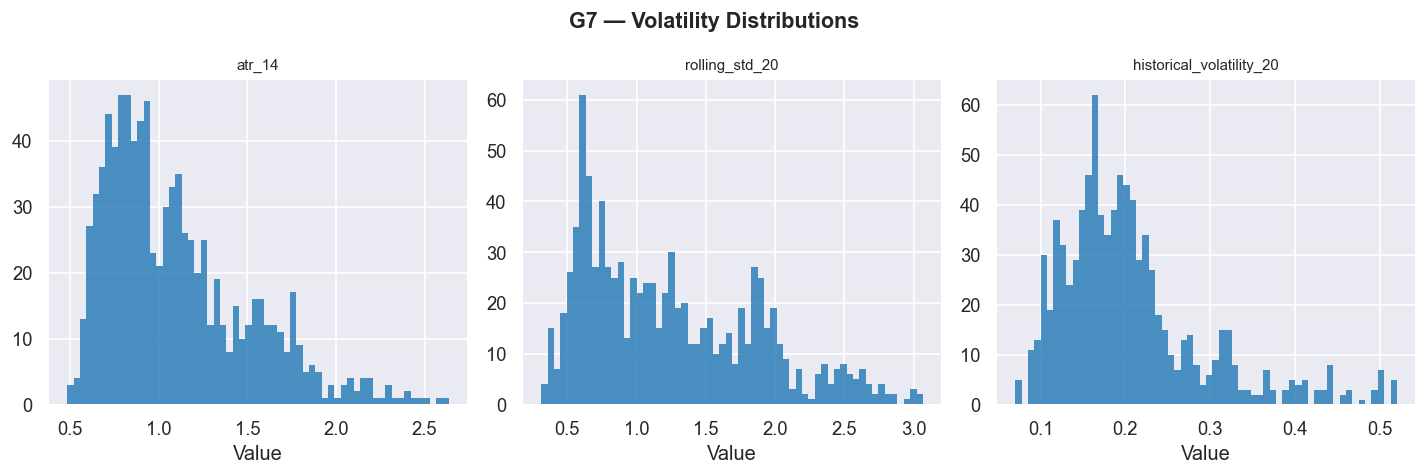

In [20]:
cols = active(G7)
if not cols:
    print('All G7 fields disabled — skipping.')
else:
    # ── 7a  Volatility indicators over time ──────────────────────────────────
    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=True)
    if n == 1: axes = [axes]
    for ax, c in zip(axes, cols):
        ax.plot(df.date, df[c], linewidth=0.9)
        ax.fill_between(df.date, df[c], alpha=0.15)
        ax.set_ylabel(c, fontsize=9)
    axes[0].set_title('G7 — Volatility Indicators Over Time', fontsize=13, fontweight='bold')
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    plt.tight_layout(); plt.show()

    # ── 7b  Distributions ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for ax, c in zip(axes, cols):
        ax.hist(df[c].dropna(), bins=60, edgecolor='none', alpha=0.8)
        ax.set_title(c, fontsize=9); ax.set_xlabel('Value')
    fig.suptitle('G7 — Volatility Distributions', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

## Nhóm 8 — Thống kê Cửa sổ trượt & Bối cảnh Thị trường
**Thống kê giá:** `rolling_max_20, rolling_min_20, distance_from_high_20, distance_from_low_20`  
**Thị trường chung:** `vnindex, vnindex_volume, vnindex_return, correlation_market_20, beta_20`

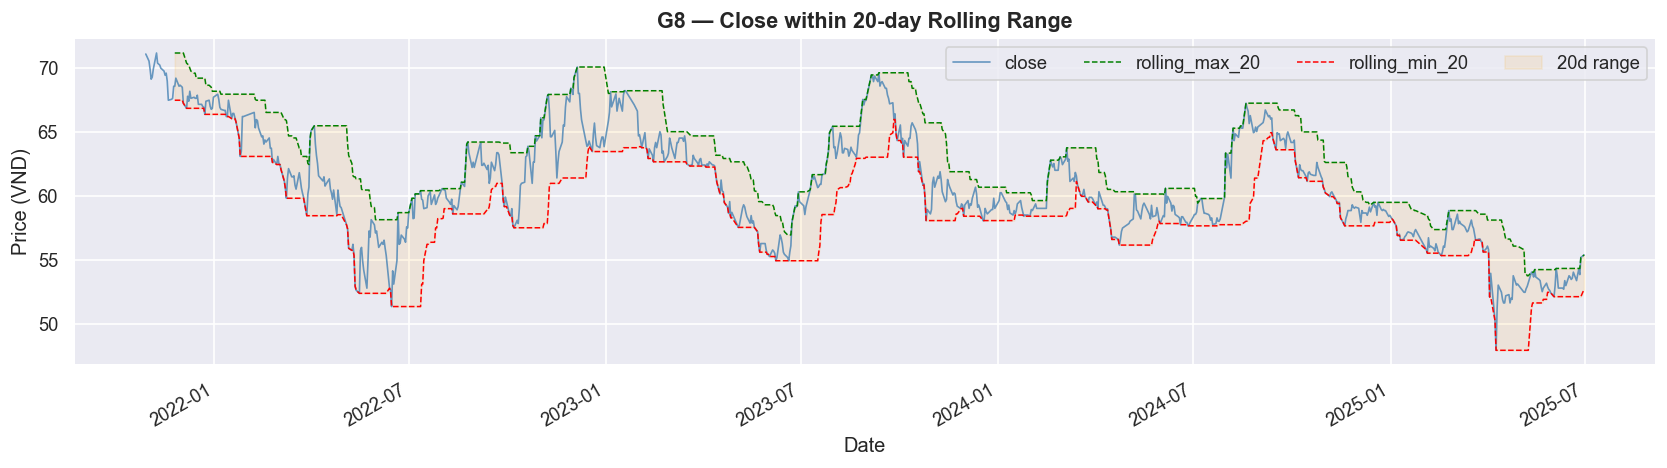

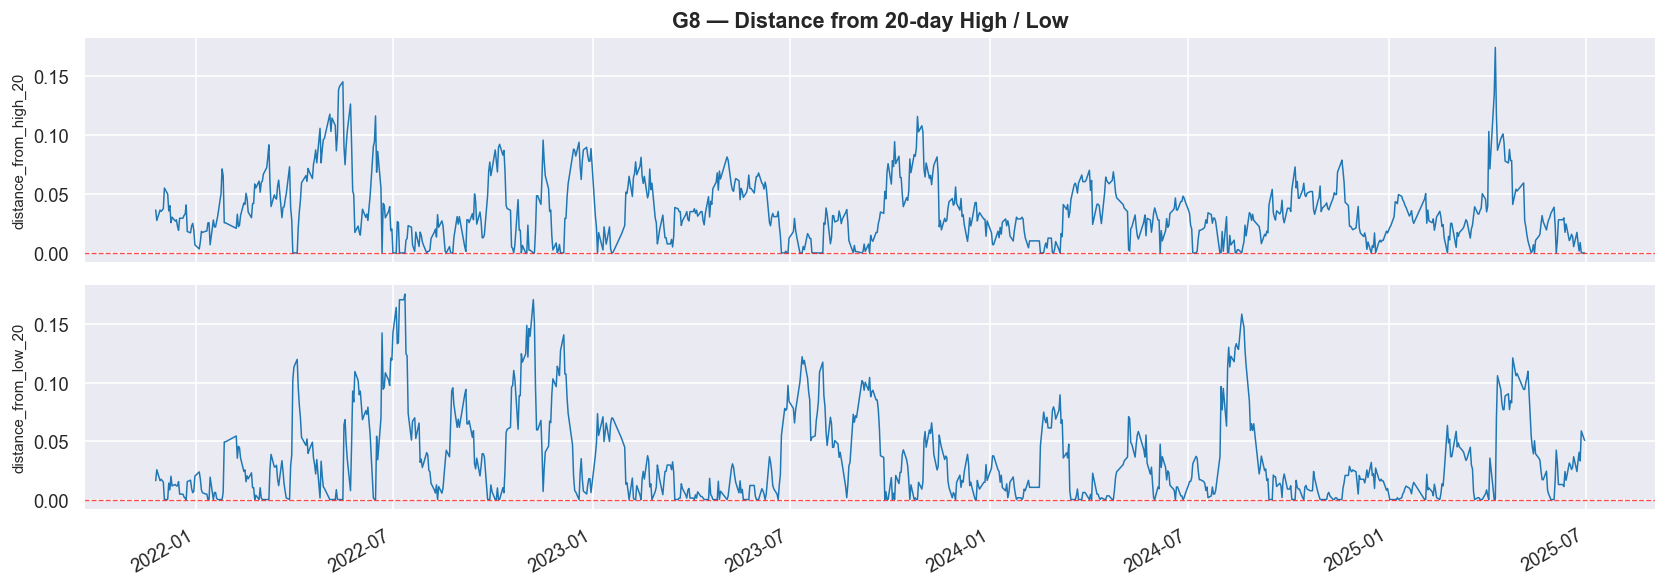

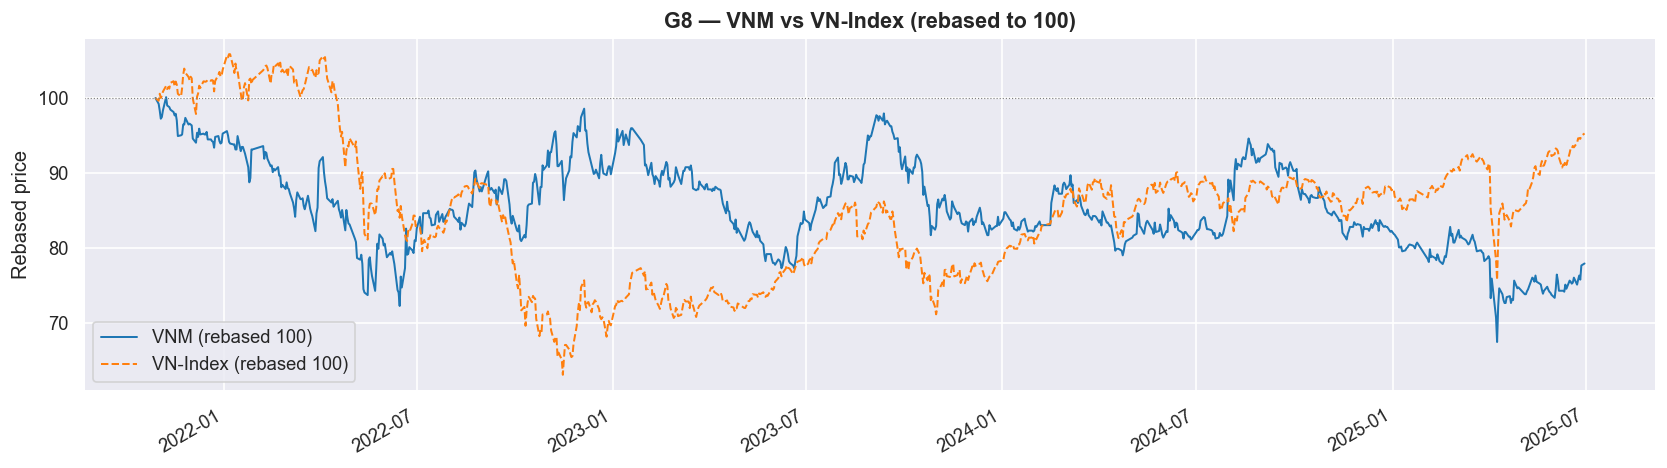

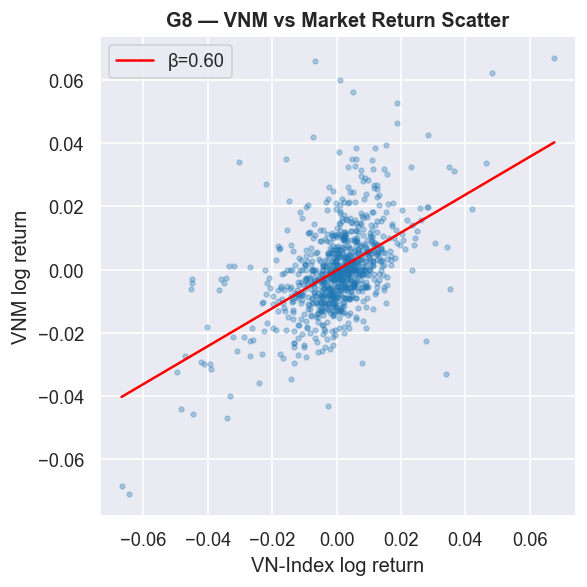

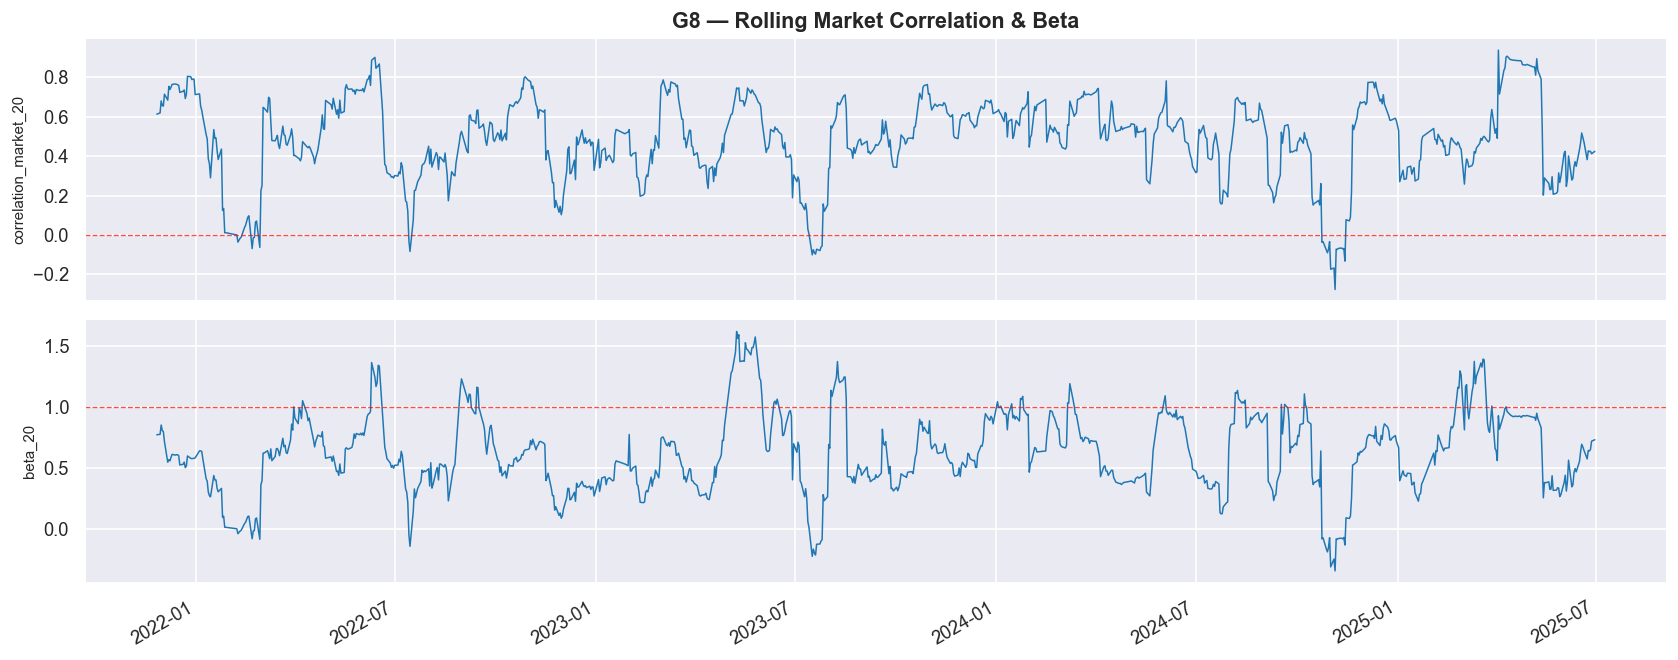

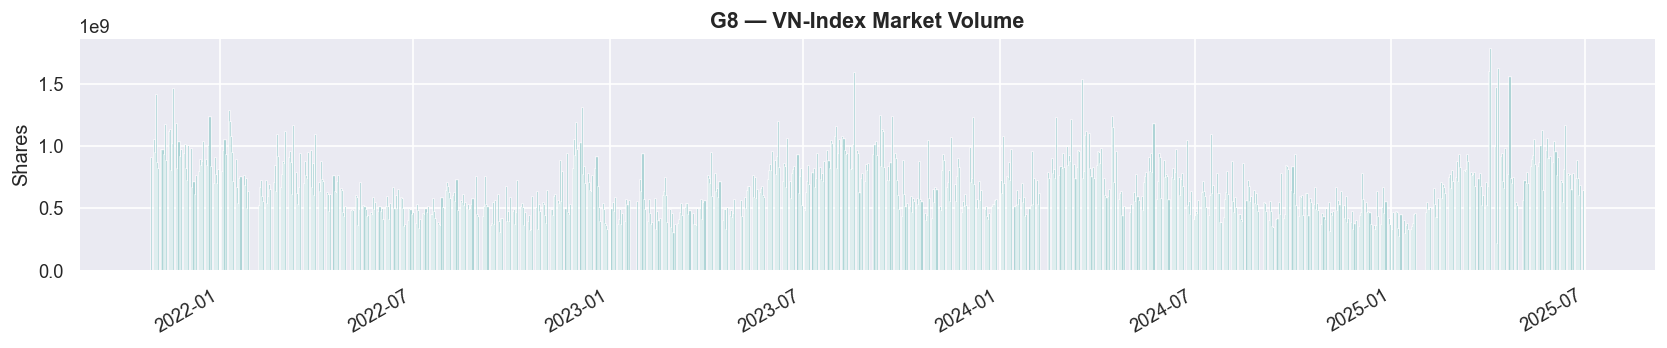

In [12]:
cols = active(G8)
if not cols:
    print('All G8 fields disabled — skipping.')
else:
    price_stat_cols = [c for c in ['rolling_max_20','rolling_min_20',
                                    'distance_from_high_20','distance_from_low_20'] if c in cols]
    idx_price_cols  = [c for c in ['vnindex'] if c in cols]
    idx_vol_cols    = [c for c in ['vnindex_volume'] if c in cols]
    idx_ret_cols    = [c for c in ['vnindex_return'] if c in cols]
    roll_stat_cols  = [c for c in ['correlation_market_20','beta_20'] if c in cols]

    # ── 8a  Close within 20-day rolling range ───────────────────────────────
    range_cols = [c for c in ['rolling_max_20','rolling_min_20'] if c in price_stat_cols]
    if range_cols and 'close' in df.columns:
        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(df.date, df.close, color='steelblue', linewidth=1, label='close', alpha=0.8)
        if 'rolling_max_20' in range_cols:
            ax.plot(df.date, df.rolling_max_20, color='green', linewidth=0.9,
                    linestyle='--', label='rolling_max_20')
        if 'rolling_min_20' in range_cols:
            ax.plot(df.date, df.rolling_min_20, color='red', linewidth=0.9,
                    linestyle='--', label='rolling_min_20')
        if len(range_cols) == 2:
            ax.fill_between(df.date, df.rolling_min_20, df.rolling_max_20,
                             alpha=0.1, color='orange', label='20d range')
        ax.set_title('G8 — Close within 20-day Rolling Range', fontsize=13, fontweight='bold')
        ax.set_xlabel('Date'); ax.set_ylabel('Price (VND)')
        ax.legend(ncol=4); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()
        plt.tight_layout(); plt.show()

    # ── 8b  Distance from 20-day High / Low ─────────────────────────────────
    dist_cols = [c for c in ['distance_from_high_20','distance_from_low_20']
                 if c in price_stat_cols]
    if dist_cols:
        n_d = len(dist_cols)
        fig, axes = plt.subplots(n_d, 1, figsize=(14, 2.5*n_d), sharex=True)
        if n_d == 1: axes = [axes]
        for ax, c in zip(axes, dist_cols):
            ax.plot(df.date, df[c], linewidth=0.9)
            ax.axhline(0, color='red', linewidth=0.8, linestyle='--', alpha=0.7)
            ax.set_ylabel(c, fontsize=9)
        axes[0].set_title('G8 — Distance from 20-day High / Low',
                          fontsize=13, fontweight='bold')
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()
        plt.tight_layout(); plt.show()

    # ── 8c  VNM vs VN-Index (rebased to 100) ────────────────────────────────
    if idx_price_cols and 'close' in df.columns:
        fig, ax = plt.subplots(figsize=(14, 4))
        vnm_n = df.close   / df.close.iloc[0]   * 100
        vni_n = df.vnindex / df.vnindex.iloc[0] * 100
        ax.plot(df.date, vnm_n, label='VNM (rebased 100)', linewidth=1.2)
        ax.plot(df.date, vni_n, label='VN-Index (rebased 100)',
                linewidth=1.2, linestyle='--')
        ax.axhline(100, color='gray', linewidth=0.7, linestyle=':')
        ax.set_title('G8 — VNM vs VN-Index (rebased to 100)', fontsize=13, fontweight='bold')
        ax.set_ylabel('Rebased price'); ax.legend()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()
        plt.tight_layout(); plt.show()

    # ── 8d  Return scatter: VNM vs VN-Index ─────────────────────────────────
    if idx_ret_cols and 'log_return' in df.columns:
        fig, ax = plt.subplots(figsize=(5, 5))
        sub = df[['log_return','vnindex_return']].dropna()
        ax.scatter(sub.vnindex_return, sub.log_return, alpha=0.3, s=8)
        m, b = np.polyfit(sub.vnindex_return, sub.log_return, 1)
        xs = np.linspace(sub.vnindex_return.min(), sub.vnindex_return.max(), 200)
        ax.plot(xs, m*xs+b, color='red', linewidth=1.5, label=f'β={m:.2f}')
        ax.set_xlabel('VN-Index log return'); ax.set_ylabel('VNM log return')
        ax.set_title('G8 — VNM vs Market Return Scatter', fontsize=12, fontweight='bold')
        ax.legend()
        plt.tight_layout(); plt.show()

    # ── 8e  Rolling correlation and beta ─────────────────────────────────────
    if roll_stat_cols:
        n_r = len(roll_stat_cols)
        fig, axes = plt.subplots(n_r, 1, figsize=(14, 2.8*n_r), sharex=True)
        if n_r == 1: axes = [axes]
        ref = {'correlation_market_20': 0, 'beta_20': 1.0}
        for ax, c in zip(axes, roll_stat_cols):
            ax.plot(df.date, df[c], linewidth=0.9)
            ax.axhline(ref[c], color='red', linewidth=0.8, linestyle='--', alpha=0.7)
            ax.set_ylabel(c, fontsize=9)
        axes[0].set_title('G8 — Rolling Market Correlation & Beta',
                          fontsize=13, fontweight='bold')
        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()
        plt.tight_layout(); plt.show()

    # ── 8f  VN-Index volume ───────────────────────────────────────────────────
    if idx_vol_cols:
        fig, ax = plt.subplots(figsize=(14, 3))
        ax.bar(df.date, df.vnindex_volume, color='teal', alpha=0.6, width=1)
        ax.set_title('G8 — VN-Index Market Volume', fontsize=13, fontweight='bold')
        ax.set_ylabel('Shares')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        fig.autofmt_xdate()
        plt.tight_layout(); plt.show()